#Importing

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#EDA

In [86]:
data=pd.read_csv('/content/drive/MyDrive/Student_Exam_Performance (1).csv')

In [87]:
data.head()

,Gender,Parental Education Level,Lunch Type,Test Preparation Course,Study Time,Absences,Math Score,Reading Score,Writing Score
0,Male,Bachelor,Standard,Completed,7.0,0,91.911467,83.495543,89.545740
1,Female,Associate,Free/Reduced,NaN,3.0,4,53.368888,46.932742,60.787848
2,Male,Associate,Standard,Completed,6.0,5,78.681731,78.613855,82.795338
3,Female,Bachelor,Free/Reduced,NaN,0.0,1,40.716589,38.756995,45.371510
4,Male,Bachelor,Free/Reduced,Completed,2.0,11,52.541330,53.477615,66.229557


In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    1000 non-null   object 
 1   Parental Education Level  966 non-null    object 
 2   Lunch Type                963 non-null    object 
 3   Test Preparation Course   477 non-null    object 
 4   Study Time                955 non-null    float64
 5   Absences                  1000 non-null   int64  
 6   Math Score                956 non-null    float64
 7   Reading Score             1000 non-null   float64
 8   Writing Score             1000 non-null   float64
dtypes: float64(4), int64(1), object(4)
memory usage: 70.4+ KB


In [89]:
data.describe()

,Study Time,Absences,Math Score,Reading Score,Writing Score
count,955.000000,1000.000000,956.000000,1000.000000,1000.000000
mean,4.973822,9.978000,69.402547,69.283699,69.047066
std,3.169288,6.098747,17.220734,17.375916,17.528838
min,0.000000,0.000000,30.330340,30.255916,30.180634
25%,2.000000,5.000000,55.725599,55.777963,54.421867
50%,5.000000,10.000000,69.242526,69.278669,68.744687
75%,8.000000,15.000000,82.982720,83.060793,83.349836
max,10.000000,20.000000,100.000000,100.000000,100.000000


In [90]:
round(data.isnull().sum()/len(data)*100,2)

,0
Gender,0.0
Parental Education Level,3.4
Lunch Type,3.7
Test Preparation Course,52.3
Study Time,4.5
Absences,0.0
Math Score,4.4
Reading Score,0.0
Writing Score,0.0


In [91]:
data['Parental Education Level'].value_counts()

,count
Parental Education Level,
Master,222
High School,205
Bachelor,192
PhD,184
Associate,163


In [92]:
data['Lunch Type'].value_counts()

,count
Lunch Type,
Standard,491
Free/Reduced,472


In [93]:
data['Test Preparation Course'].value_counts()

,count
Test Preparation Course,
Completed,477


#Data Cleaning

In [94]:
data.drop_duplicates()

,Gender,Parental Education Level,Lunch Type,Test Preparation Course,Study Time,Absences,Math Score,Reading Score,Writing Score
0,Male,Bachelor,Standard,Completed,7.0,0,91.911467,83.495543,89.545740
1,Female,Associate,Free/Reduced,NaN,3.0,4,53.368888,46.932742,60.787848
2,Male,Associate,Standard,Completed,6.0,5,78.681731,78.613855,82.795338
3,Female,Bachelor,Free/Reduced,NaN,0.0,1,40.716589,38.756995,45.371510
4,Male,Bachelor,Free/Reduced,Completed,2.0,11,52.541330,53.477615,66.229557
...,...,...,...,...,...,...,...,...,...
995,Female,Bachelor,Free/Reduced,Completed,9.0,12,100.000000,94.434158,100.000000
996,Female,High School,Free/Reduced,Completed,0.0,7,45.748670,56.308491,45.657687
997,Male,Master,Free/Reduced,NaN,6.0,20,74.720793,72.730035,73.302004
998,Male,NaN,Free/Reduced,NaN,10.0,5,99.417128,91.867564,97.786900


In [95]:
# Handling nan values in column Math Score

data['Reading_bin'] = pd.qcut(data['Reading Score'], q=5)
data['Writing_bin'] = pd.qcut(data['Writing Score'], q=5)

data['Math Score'] = data.groupby(
    ['Reading_bin', 'Writing_bin']
)['Math Score'].transform(
    lambda x: x.fillna(x.median())
)

data['Math Score'].fillna(data['Math Score'].median(), inplace=True)

In [96]:
round(data.isnull().sum()/len(data)*100,2)

,0
Gender,0.0
Parental Education Level,3.4
Lunch Type,3.7
Test Preparation Course,52.3
Study Time,4.5
Absences,0.0
Math Score,0.0
Reading Score,0.0
Writing Score,0.0
Reading_bin,0.0


In [97]:
# Handling nan values in column Parental Education Level

data['Math_bin'] = pd.qcut(data['Math Score'], q=5)


data['Parental Education Level'] = data.groupby(
    ['Math_bin', 'Reading_bin', 'Writing_bin']
)['Parental Education Level'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

data['Parental Education Level'].fillna(
    data['Parental Education Level'].mode()[0],
    inplace=True
)

In [98]:
round(data.isnull().sum()/len(data)*100,2)

,0
Gender,0.0
Parental Education Level,0.0
Lunch Type,3.7
Test Preparation Course,52.3
Study Time,4.5
Absences,0.0
Math Score,0.0
Reading Score,0.0
Writing Score,0.0
Reading_bin,0.0


In [99]:
data.head()

,Gender,Parental Education Level,Lunch Type,Test Preparation Course,Study Time,Absences,Math Score,Reading Score,Writing Score,Reading_bin,Writing_bin,Math_bin
0,Male,Bachelor,Standard,Completed,7.0,0,91.911467,83.495543,89.545740,"(75.035, 86.746]","(85.923, 100.0]","(85.697, 100.0]"
1,Female,Associate,Free/Reduced,NaN,3.0,4,53.368888,46.932742,60.787848,"(30.255, 52.407]","(51.518, 64.102]","(52.458, 63.827]"
2,Male,Associate,Standard,Completed,6.0,5,78.681731,78.613855,82.795338,"(75.035, 86.746]","(74.747, 85.923]","(75.009, 85.697]"
3,Female,Bachelor,Free/Reduced,NaN,0.0,1,40.716589,38.756995,45.371510,"(30.255, 52.407]","(30.18, 51.518]","(30.328999999999997, 52.458]"
4,Male,Bachelor,Free/Reduced,Completed,2.0,11,52.541330,53.477615,66.229557,"(52.407, 63.716]","(64.102, 74.747]","(52.458, 63.827]"


In [100]:
data['Lunch Type'] = data.groupby(
    ['Math_bin', 'Reading_bin', 'Writing_bin']
)['Lunch Type'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

data['Lunch Type'].fillna(
    data['Lunch Type'].mode()[0],
    inplace=True
)

In [101]:
round(data.isnull().sum()/len(data)*100,2)

,0
Gender,0.0
Parental Education Level,0.0
Lunch Type,0.0
Test Preparation Course,52.3
Study Time,4.5
Absences,0.0
Math Score,0.0
Reading Score,0.0
Writing Score,0.0
Reading_bin,0.0


In [102]:
# Handling nan values in column Test Preparation Course

data['Test Preparation Course'] = data.groupby(
    ['Math_bin', 'Reading_bin', 'Writing_bin']
)['Test Preparation Course'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

data['Test Preparation Course'].fillna(
    data['Test Preparation Course'].mode()[0],
    inplace=True
)

In [103]:
round(data.isnull().sum()/len(data)*100,2)

,0
Gender,0.0
Parental Education Level,0.0
Lunch Type,0.0
Test Preparation Course,0.0
Study Time,4.5
Absences,0.0
Math Score,0.0
Reading Score,0.0
Writing Score,0.0
Reading_bin,0.0


In [104]:
# Handling nan values in column Study Time

data['Study Time'] = data.groupby(
    ['Math_bin', 'Reading_bin', 'Writing_bin', 'Test Preparation Course']
)['Study Time'].transform(
    lambda x: x.fillna(x.median())
)

data['Study Time'].fillna(data['Study Time'].median(), inplace=True)

In [105]:
round(data.isnull().sum()/len(data)*100,2)

,0
Gender,0.0
Parental Education Level,0.0
Lunch Type,0.0
Test Preparation Course,0.0
Study Time,0.0
Absences,0.0
Math Score,0.0
Reading Score,0.0
Writing Score,0.0
Reading_bin,0.0


In [106]:
data['Test Preparation Course'].value_counts()

,count
Test Preparation Course,
Completed,1000


In [107]:
data.shape

(1000, 12)

In [108]:
data.head()

,Gender,Parental Education Level,Lunch Type,Test Preparation Course,Study Time,Absences,Math Score,Reading Score,Writing Score,Reading_bin,Writing_bin,Math_bin
0,Male,Bachelor,Standard,Completed,7.0,0,91.911467,83.495543,89.545740,"(75.035, 86.746]","(85.923, 100.0]","(85.697, 100.0]"
1,Female,Associate,Free/Reduced,Completed,3.0,4,53.368888,46.932742,60.787848,"(30.255, 52.407]","(51.518, 64.102]","(52.458, 63.827]"
2,Male,Associate,Standard,Completed,6.0,5,78.681731,78.613855,82.795338,"(75.035, 86.746]","(74.747, 85.923]","(75.009, 85.697]"
3,Female,Bachelor,Free/Reduced,Completed,0.0,1,40.716589,38.756995,45.371510,"(30.255, 52.407]","(30.18, 51.518]","(30.328999999999997, 52.458]"
4,Male,Bachelor,Free/Reduced,Completed,2.0,11,52.541330,53.477615,66.229557,"(52.407, 63.716]","(64.102, 74.747]","(52.458, 63.827]"


# Data Preprocessing

In [109]:
data = pd.get_dummies(data,columns=['Gender', 'Parental Education Level', 'Lunch Type'],drop_first=True)

In [110]:
data.head()

,Test Preparation Course,Study Time,Absences,Math Score,Reading Score,Writing Score,Reading_bin,Writing_bin,Math_bin,Gender_Male,Parental Education Level_Bachelor,Parental Education Level_High School,Parental Education Level_Master,Parental Education Level_PhD,Lunch Type_Standard
0,Completed,7.0,0,91.911467,83.495543,89.545740,"(75.035, 86.746]","(85.923, 100.0]","(85.697, 100.0]",True,True,False,False,False,True
1,Completed,3.0,4,53.368888,46.932742,60.787848,"(30.255, 52.407]","(51.518, 64.102]","(52.458, 63.827]",False,False,False,False,False,False
2,Completed,6.0,5,78.681731,78.613855,82.795338,"(75.035, 86.746]","(74.747, 85.923]","(75.009, 85.697]",True,False,False,False,False,True
3,Completed,0.0,1,40.716589,38.756995,45.371510,"(30.255, 52.407]","(30.18, 51.518]","(30.328999999999997, 52.458]",False,True,False,False,False,False
4,Completed,2.0,11,52.541330,53.477615,66.229557,"(52.407, 63.716]","(64.102, 74.747]","(52.458, 63.827]",True,True,False,False,False,False


# Feature engineering

In [111]:
data['Average Score'] = (data['Math Score'] +data['Reading Score'] +data['Writing Score']) / 3

In [112]:
data.head()

,Test Preparation Course,Study Time,Absences,Math Score,Reading Score,Writing Score,Reading_bin,Writing_bin,Math_bin,Gender_Male,Parental Education Level_Bachelor,Parental Education Level_High School,Parental Education Level_Master,Parental Education Level_PhD,Lunch Type_Standard,Average Score
0,Completed,7.0,0,91.911467,83.495543,89.545740,"(75.035, 86.746]","(85.923, 100.0]","(85.697, 100.0]",True,True,False,False,False,True,88.317583
1,Completed,3.0,4,53.368888,46.932742,60.787848,"(30.255, 52.407]","(51.518, 64.102]","(52.458, 63.827]",False,False,False,False,False,False,53.696493
2,Completed,6.0,5,78.681731,78.613855,82.795338,"(75.035, 86.746]","(74.747, 85.923]","(75.009, 85.697]",True,False,False,False,False,True,80.030308
3,Completed,0.0,1,40.716589,38.756995,45.371510,"(30.255, 52.407]","(30.18, 51.518]","(30.328999999999997, 52.458]",False,True,False,False,False,False,41.615031
4,Completed,2.0,11,52.541330,53.477615,66.229557,"(52.407, 63.716]","(64.102, 74.747]","(52.458, 63.827]",True,True,False,False,False,False,57.416167


# Data Visualization

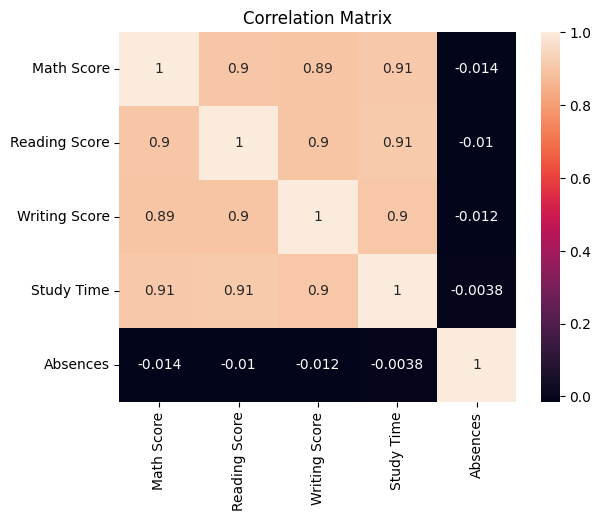

In [113]:
sns.heatmap(
    data[['Math Score','Reading Score','Writing Score','Study Time','Absences']].corr(),
    annot=True
)
plt.title("Correlation Matrix")
plt.show()

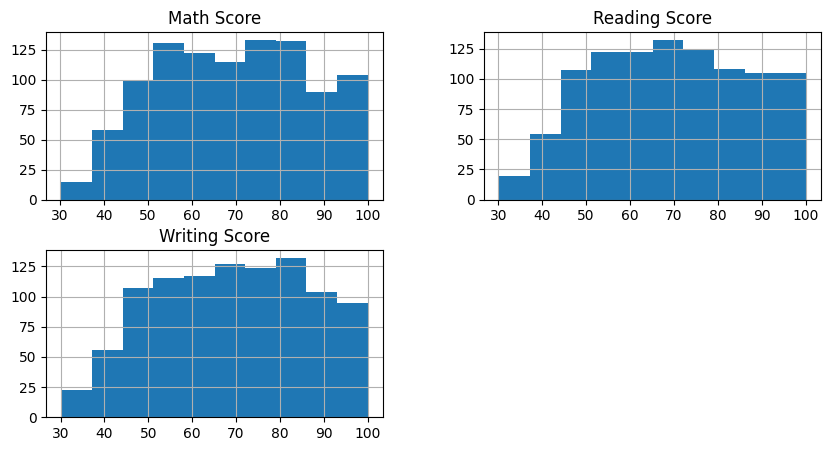

In [114]:
data[['Math Score','Reading Score','Writing Score']].hist(figsize=(10,5))
plt.show()

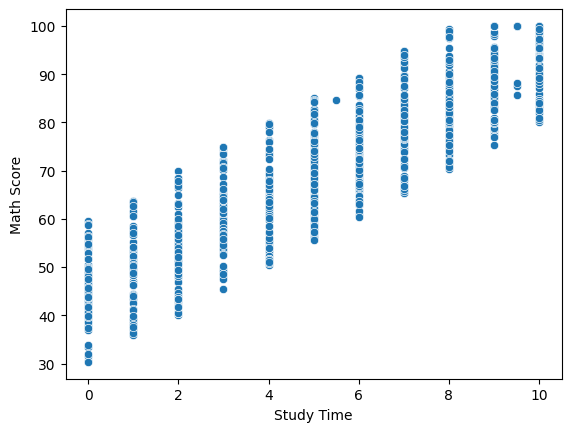

In [115]:
sns.scatterplot(x='Study Time', y='Math Score', data=data)
plt.show()

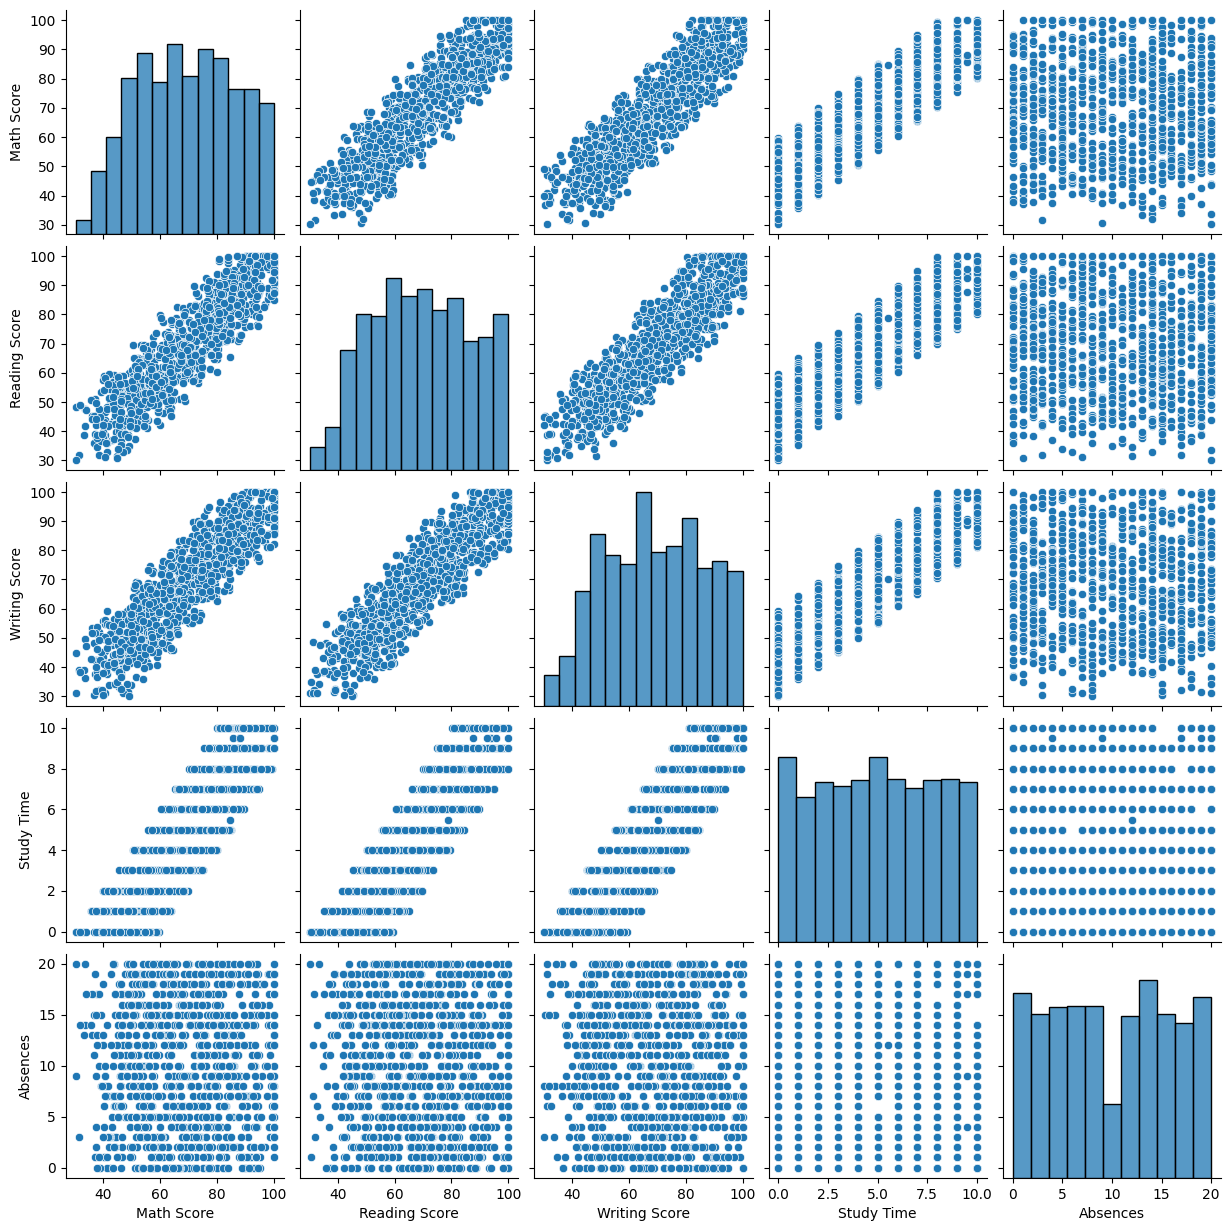

In [116]:
sns.pairplot(data[['Math Score','Reading Score','Writing Score','Study Time','Absences']])
plt.show()

# Modeling

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

cols_to_drop = ['Test Preparation Course', 'Math_bin', 'Reading_bin', 'Writing_bin','Math Score','Reading Score','Writing Score']
data_model = data.drop(columns=cols_to_drop, errors='ignore')

X = data_model.drop('Average Score', axis=1)
y = data_model['Average Score']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))

Train R2: 0.9090797358084175
Test R2: 0.8857731291379489
Test MAE: 5.106661103025738
